Saving Social_Network_Ads.csv to Social_Network_Ads.csv
Decision Tree Accuracy: 0.8333333333333334
Decision Tree Precision: 0.8
Decision Tree Recall: 0.7659574468085106


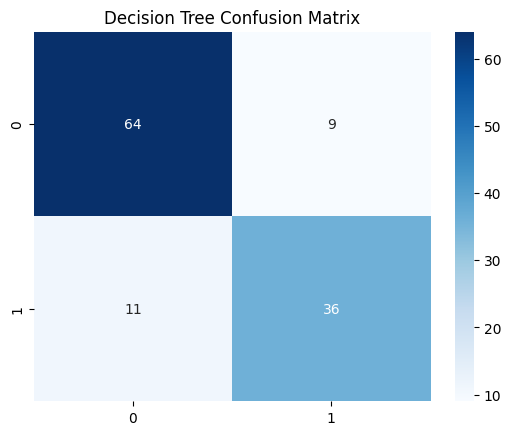

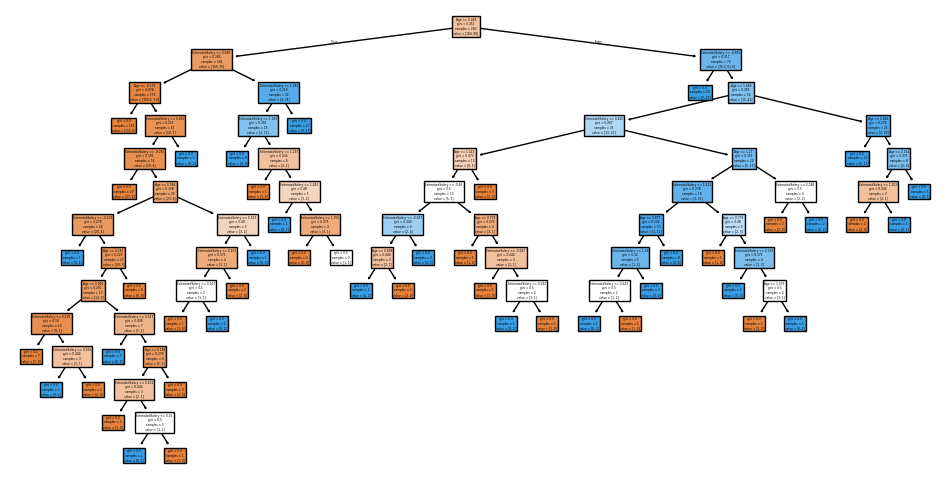

In [2]:
# --- Decision Tree Classifier with File Upload ---

from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Upload dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

# Prepare data
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, Y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Decision Tree Accuracy:", accuracy_score(Y_test, y_pred))
print("Decision Tree Precision:", precision_score(Y_test, y_pred))
print("Decision Tree Recall:", recall_score(Y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Plot Tree
plt.figure(figsize=(12,6))
plot_tree(model, feature_names=['Age', 'EstimatedSalary'], filled=True)
plt.show()
